# Beta Distribution Visualizer for Proteina Noise Schedule

Interactive visualizer for the `mix_up02_beta` noise schedule used in Proteina training.
The training noise level `t` is sampled as: 98% from `Beta(p1, p2)` + 2% from `Uniform(0, 1)`.

- `t` close to 1 = mostly clean data (x_t close to x_1)
- `t` close to 0 = mostly Gaussian noise (x_t close to x_0)

Adjust sliders to explore how p1/p2 shape the noise curriculum.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets
from IPython.display import display

%matplotlib widget

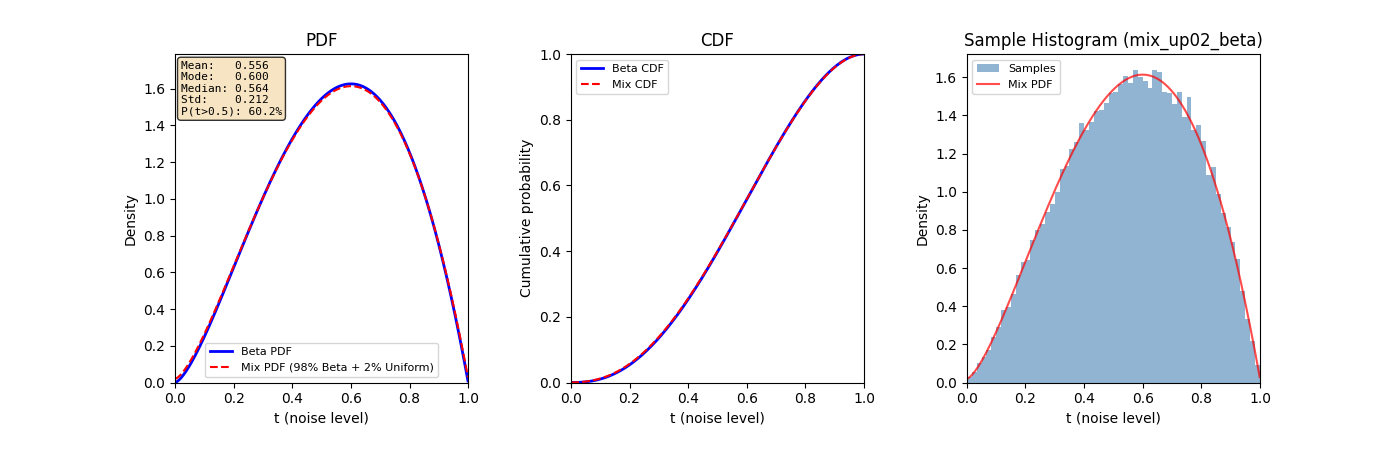

In [2]:
def make_visualizer():
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    fig.subplots_adjust(wspace=0.35, bottom=0.15)

    t = np.linspace(0.001, 0.999, 500)
    n_samples = 50_000
    uniform_weight = 0.02

    # Sliders
    p1_slider = widgets.FloatSlider(value=2.5, min=0.1, max=10.0, step=0.1,
                                     description='p1 (alpha):', style={'description_width': '80px'},
                                     layout=widgets.Layout(width='400px'))
    p2_slider = widgets.FloatSlider(value=2.0, min=0.1, max=10.0, step=0.1,
                                     description='p2 (beta):', style={'description_width': '80px'},
                                     layout=widgets.Layout(width='400px'))

    # Initial plot elements
    line_pdf, = axes[0].plot(t, stats.beta.pdf(t, 2.5, 2.0), 'b-', lw=2, label='Beta PDF')
    line_mix, = axes[0].plot(t, np.ones_like(t), 'r--', lw=1.5, label='Mix PDF (98% Beta + 2% Uniform)')
    axes[0].set_xlabel('t (noise level)')
    axes[0].set_ylabel('Density')
    axes[0].set_title('PDF')
    axes[0].legend(fontsize=8)
    axes[0].set_xlim(0, 1)

    line_cdf, = axes[1].plot(t, stats.beta.cdf(t, 2.5, 2.0), 'b-', lw=2, label='Beta CDF')
    line_mix_cdf, = axes[1].plot(t, np.ones_like(t), 'r--', lw=1.5, label='Mix CDF')
    axes[1].set_xlabel('t (noise level)')
    axes[1].set_ylabel('Cumulative probability')
    axes[1].set_title('CDF')
    axes[1].legend(fontsize=8)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)

    # Histogram
    rng = np.random.default_rng(42)
    samples_init = rng.beta(2.5, 2.0, size=n_samples)
    _, _, bars = axes[2].hist(samples_init, bins=60, density=True, alpha=0.6, color='steelblue', label='Samples')
    axes[2].set_xlabel('t (noise level)')
    axes[2].set_ylabel('Density')
    axes[2].set_title('Sample Histogram (mix_up02_beta)')
    axes[2].set_xlim(0, 1)

    # Stats text
    stats_text = axes[0].text(0.02, 0.98, '', transform=axes[0].transAxes,
                               fontsize=8, verticalalignment='top',
                               fontfamily='monospace',
                               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    def update(change=None):
        p1, p2 = p1_slider.value, p2_slider.value

        # PDF
        pdf_vals = stats.beta.pdf(t, p1, p2)
        mix_pdf = (1 - uniform_weight) * pdf_vals + uniform_weight * 1.0
        line_pdf.set_ydata(pdf_vals)
        line_mix.set_ydata(mix_pdf)
        y_max = max(pdf_vals.max(), mix_pdf.max()) * 1.1
        axes[0].set_ylim(0, max(y_max, 0.5))

        # CDF
        cdf_vals = stats.beta.cdf(t, p1, p2)
        mix_cdf = (1 - uniform_weight) * cdf_vals + uniform_weight * t
        line_cdf.set_ydata(cdf_vals)
        line_mix_cdf.set_ydata(mix_cdf)

        # Stats
        mean = p1 / (p1 + p2)
        var = (p1 * p2) / ((p1 + p2)**2 * (p1 + p2 + 1))
        mode = (p1 - 1) / (p1 + p2 - 2) if (p1 > 1 and p2 > 1) else float('nan')
        median = stats.beta.median(p1, p2)
        # Fraction of samples with t > 0.5 (mostly clean)
        frac_clean = 1 - stats.beta.cdf(0.5, p1, p2)
        stats_text.set_text(
            f'Mean:   {mean:.3f}\n'
            f'Mode:   {mode:.3f}\n'
            f'Median: {median:.3f}\n'
            f'Std:    {var**0.5:.3f}\n'
            f'P(t>0.5): {frac_clean:.1%}'
        )

        # Histogram - redraw
        axes[2].cla()
        rng2 = np.random.default_rng(42)
        samples_beta = rng2.beta(p1, p2, size=n_samples)
        samples_uniform = rng2.random(n_samples)
        mask = rng2.random(n_samples) < uniform_weight
        samples_mix = np.where(mask, samples_uniform, samples_beta)
        axes[2].hist(samples_mix, bins=60, density=True, alpha=0.6, color='steelblue', label='Samples')
        axes[2].plot(t, mix_pdf, 'r-', lw=1.5, alpha=0.7, label='Mix PDF')
        axes[2].set_xlabel('t (noise level)')
        axes[2].set_ylabel('Density')
        axes[2].set_title('Sample Histogram (mix_up02_beta)')
        axes[2].set_xlim(0, 1)
        axes[2].legend(fontsize=8)

        fig.canvas.draw_idle()

    p1_slider.observe(update, names='value')
    p2_slider.observe(update, names='value')

    update()  # Initial draw

    display(widgets.VBox([
        widgets.HBox([p1_slider, p2_slider]),
        fig.canvas
    ]))

make_visualizer();